<a href="https://colab.research.google.com/github/Thomas-Fabbris/applied-statistics-polimi/blob/main/Labs/Lab_IV_2026_TBC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<font size="5">Applied Statistics</font>**

<font size="3">MSc in High Performance Computing Engineering, Computer Science and Engineering, Physics Engineering, ... cod 062102</font>

A.Y. 2025-2026

Prof. Michela Carlotta Massi - Dott. Vittorio Torri

---

<font size="4">**Lab IV - DBSCAN & Gaussian Mixture Models**</font>

# Libraries

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import load_iris, make_blobs, make_moons, make_circles, load_wine
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from matplotlib.colors import Normalize
from matplotlib.patches import Ellipse
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# DBSCAN

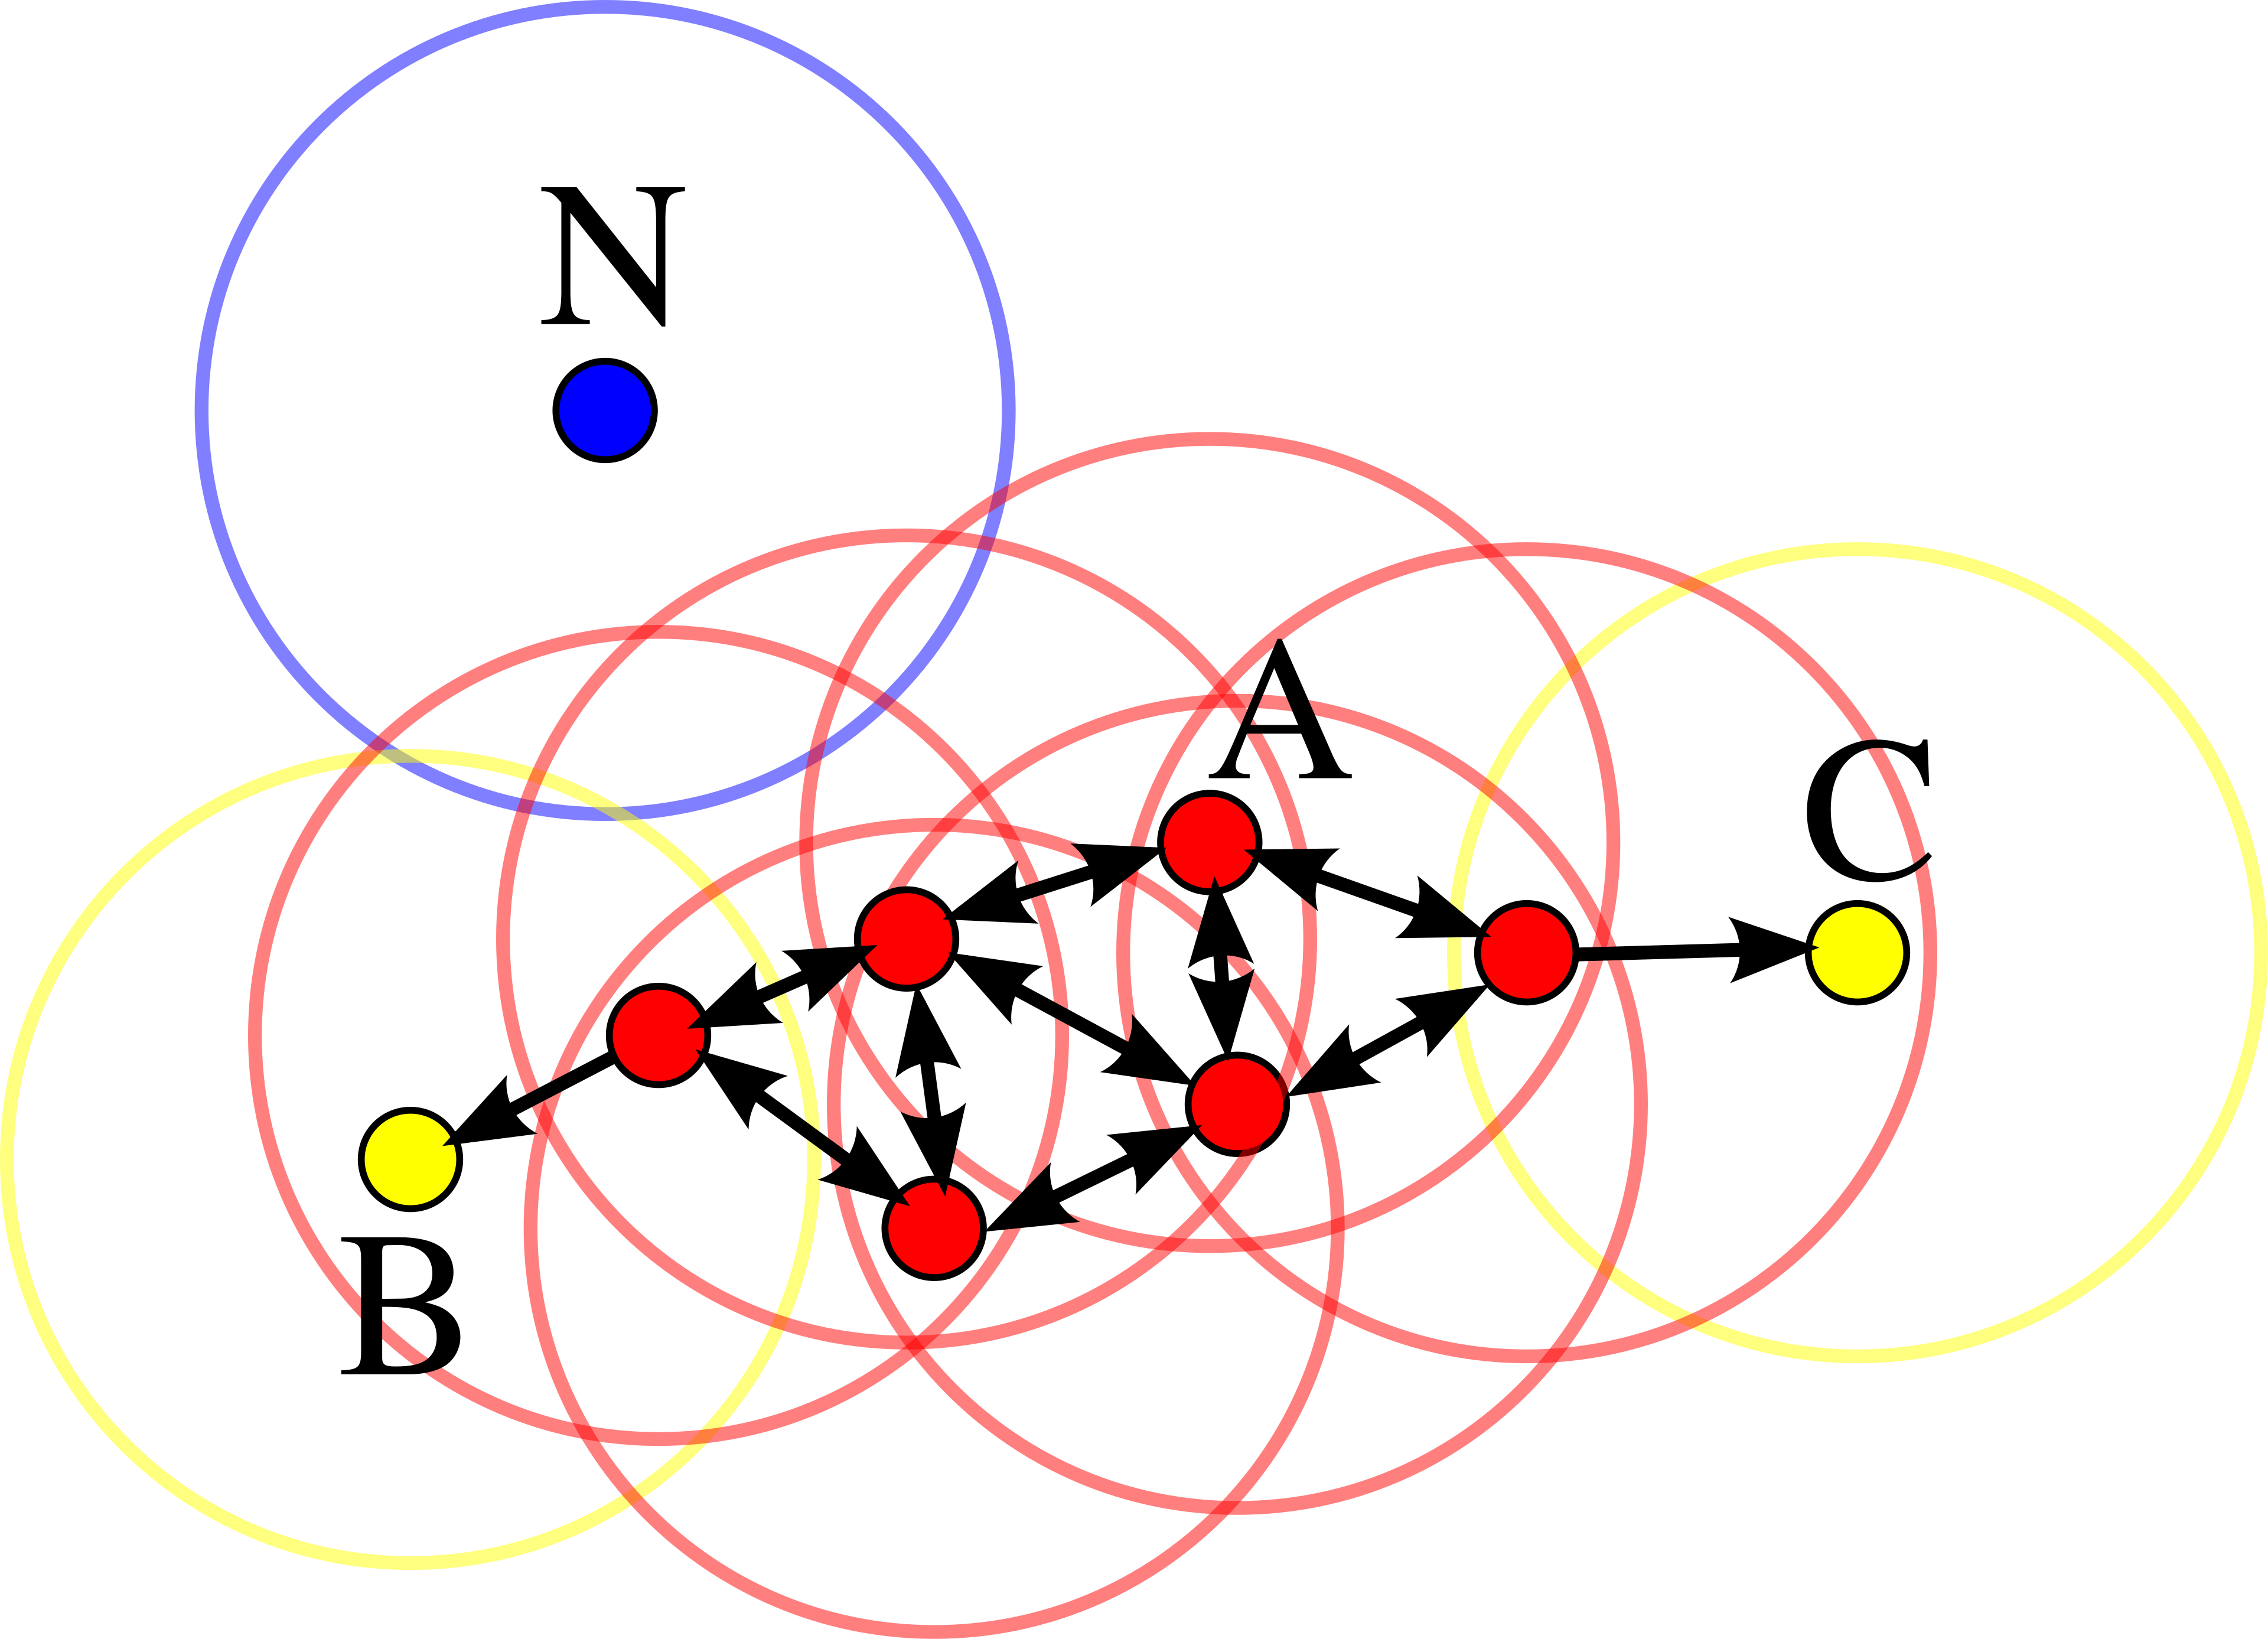

Border points fall within the radius of the region of a core point.
Noise points fall outside any neighborhood.

In [50]:
# ============================================================
# Helper for plotting DBSCAN results
# ============================================================

def plot_dbscan(ax, X, eps, min_samples, title):
    # Perform DBSCAN on X
    model = DBSCAN(eps=eps, min_samples=min_samples)
    # Points labelled with -1 are noise points
    labels = model.fit_predict(X)

    unique_labels = np.unique(labels)
    cmap = plt.get_cmap("tab10")

    for lab in unique_labels:
        mask = labels == lab
        if lab == -1:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                s=20, c="lightgray", alpha=0.8
            )
        else:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                s=20, color=cmap(lab % 10), alpha=0.8
            )

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    ax.set_title(f"{title}\nclusters = {n_clusters}, noise = {n_noise}")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_aspect("equal")
    ax.tick_params(labelbottom=False, labelleft=False)

## Noisy bubbles

Let's see an example with two clusters in a noisy setting  
Start by defining a synthetic dataset

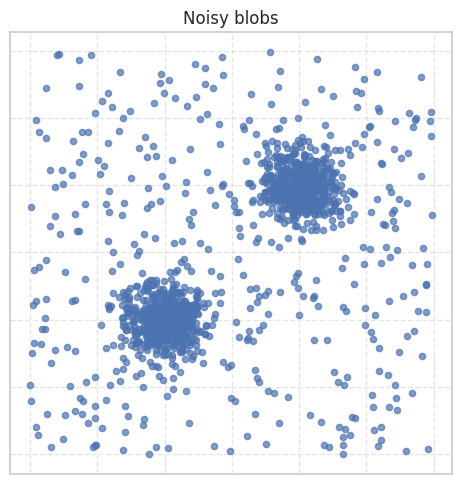

In [51]:
np.random.seed(170)

# Two dense blobs in 2-D plane (as centers feature two coordinates)
X_blobs, _ = make_blobs(
    n_samples=1000,
    centers=[[-2, -2], [2, 2]],
    cluster_std=0.6,
    random_state=170
)

# Uniform background noise
X_noise = np.random.uniform(low=-6, high=6, size=(400, 2))

# Final dataset, given by the union of X_noise and X_blobs
X = np.vstack([X_blobs, X_noise])

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7)
plt.title("Noisy blobs")
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().set_aspect("equal")
plt.tick_params(labelbottom=False, labelleft=False)
plt.tight_layout()
plt.show()

The dataset structure, with two clear clusters surrounded with some noise, is 
very common and causes many troubles with clustering algorithms, like k-means, 
that force each point to belong to a cluster

How to select `min_samples` and `epsilon`?  
epsilon is fixed by looking at the k-distance plot (plot of the distances from the k-th
nearest neighbour). The best `epsilon` happens to be in between 0.25 and 0.75 (or probably 
even up to 1.0)

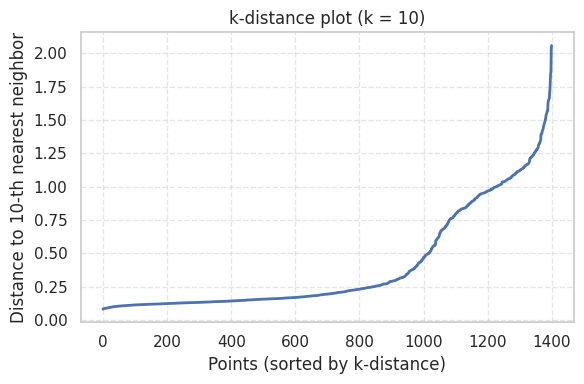

In [52]:
min_samples = 10
nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X)
distances, _ = nbrs.kneighbors(X)

# sort the last column of distances in ascending order
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances, linewidth=2)
plt.title(f"k-distance plot (k = {min_samples})")
plt.xlabel("Points (sorted by k-distance)")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

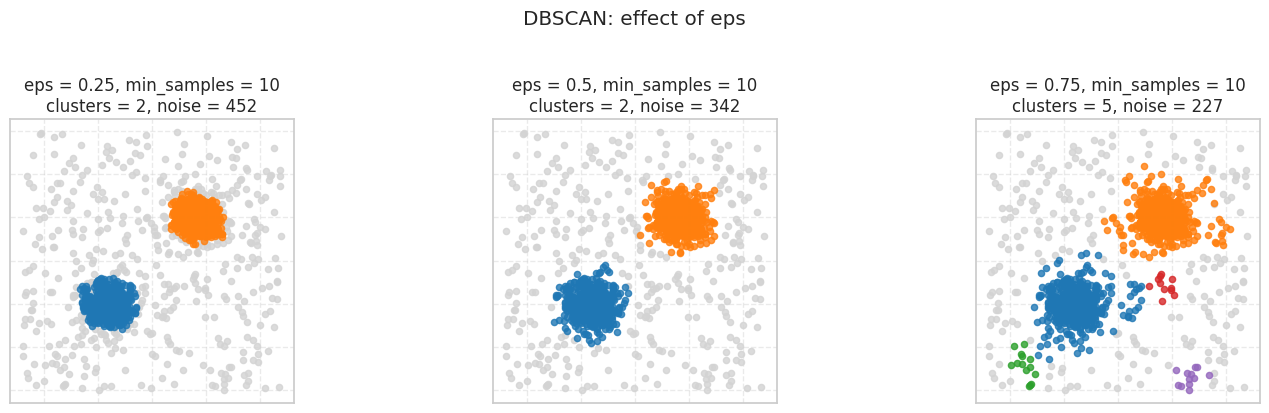

In [53]:
# ============================================================
# Effect of epsilon
# ============================================================

eps_values = [0.25, 0.50, 0.75]
min_samples = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, eps in zip(axes, eps_values):
    plot_dbscan(
        ax, X,
        eps=eps,
        min_samples=min_samples,
        title=f"eps = {eps}, min_samples = {min_samples}"
    )

# Add a centered super title to the figure
# y = y-location of the text on the figure
plt.suptitle("DBSCAN: effect of eps", y=1.03)
plt.tight_layout()
plt.show()

The best clustering appears to be the second one (comparing to the first one, 
it is just a graphical preference); of course by increasing `epsilon` too much, the 
clustering becomes less effective, and at the limit all points belong to one 
huge cluster. The opposite effect, i.e. myriad of little clusters, is reached by 
setting a very low value for `min_samples`

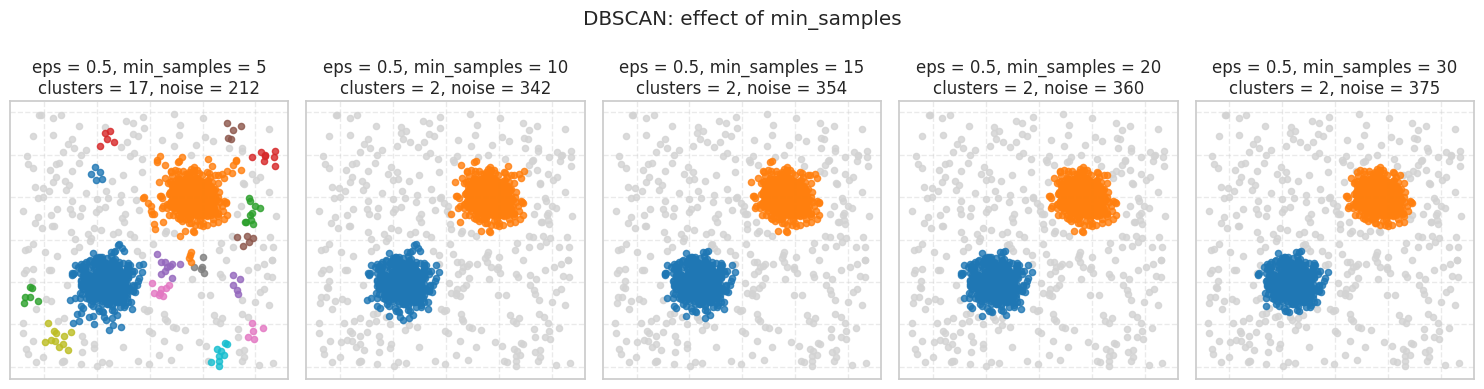

In [54]:
# ============================================================
# Effect of min_samples
# ============================================================

eps = 0.50
min_samples_values = [5, 10, 15, 20, 30]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax, ms in zip(axes, min_samples_values):
    plot_dbscan(
        ax, X,
        eps=eps,
        min_samples=ms,
        title=f"eps = {eps}, min_samples = {ms}"
    )

plt.suptitle("DBSCAN: effect of min_samples", y=1.03)
plt.tight_layout()
plt.show()

## Penguins Dataset

Sometimes, real-world data are missing and labelled as NaN in the dataset    
Here, we decide to delete all the rows featuring missing values, by calling the
Pandas `dropna()` function  
For the sake of simplicity, we perform the clustering only on numerical variables,
selecting `species` as the target variable. Our goal is to find some correlation
between the specie a penguin belong to and the other measurement performed, if any.

In [55]:
import seaborn as sns

df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


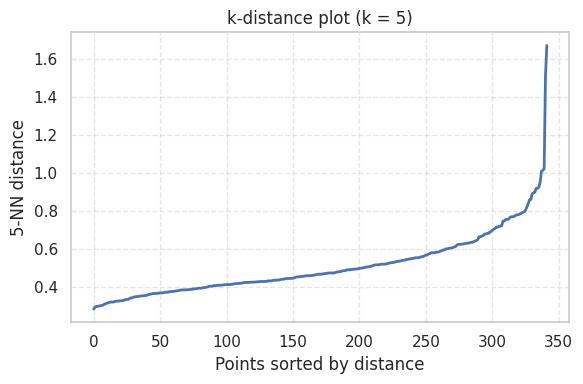

In [56]:
features = ["bill_length_mm", "bill_depth_mm",
            "flipper_length_mm", "body_mass_g"]
df = df[features + ["species"]].dropna()  # remove rows with missing values

X = df[features].values  # return a Numpy representation of the Pandas DataFrame
y = df["species"].values

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# ============================================================
# k-distance plot
# ============================================================

k = 5
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances, linewidth=2)
plt.title(f"k-distance plot (k = {k})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN distance")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

The best `epsilon` is somewhere around 0.7 and 0.8

### Adjusted Rand Index (ARI)

The Adjusted Rand Index (ARI) measures the similarity between two sets of labels (typically cluster labels vs some reference labels) while correcting for random chance. Reference labels come oftern from the value of a categorical variable, `species` in this example.  
It is defined as:

$$
\text{ARI} = \frac{\sum_{ij} \binom{n_{ij}}{2} - \left[ \sum_i \binom{a_i}{2} \sum_j \binom{b_j}{2} \right] / \binom{n}{2}}{\frac{1}{2} \left[ \sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2} \right] - \left[ \sum_i \binom{a_i}{2} \sum_j \binom{b_j}{2} \right] / \binom{n}{2}}
$$

where:
- $ n_{ij} $ is the number of elements in both cluster $ i $ in the ground truth and cluster $ j $ in the predicted clustering.
- $ a_i $ is the sum of elements in row $ i $ (total points in true cluster $ i $).
- $ b_j $ is the sum of elements in column $ j $ (total points in predicted cluster $ j $).
- $ n $ is the total number of elements.
- $ \binom{n}{2} $ represents the binomial coefficient, which counts the number of ways to choose 2 elements from $ n $.

The formula is not immediate to understand, but its interpretation is straightforward:
1. If the clustering perfectly matches the ground truth, $ \text{ARI} = 1 $.
2. If the clustering is random, $ \text{ARI} \approx 0 $.
3. If clustering is worse than random, $ \text{ARI} < 0 $.  

Usually, it is difficult to get $ \text{ARI} < 0 $ from a real-world dataset, 
without doing it by purpose

We run DBSCAN on multiple epsilon values between 0.6 and 1.0. For each of them we compute ARI and we store all the results

In [57]:
from sklearn.metrics import adjusted_rand_score
eps_values = np.linspace(0.6, 1.0, 9)
min_samples = 5

results = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    # noisy samples are given the label -1
    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    mask = labels != -1

    # ARI (excluding noise)
    ari = adjusted_rand_score(y[mask], labels[mask])

    results.append((eps, n_clusters, n_noise, ari))

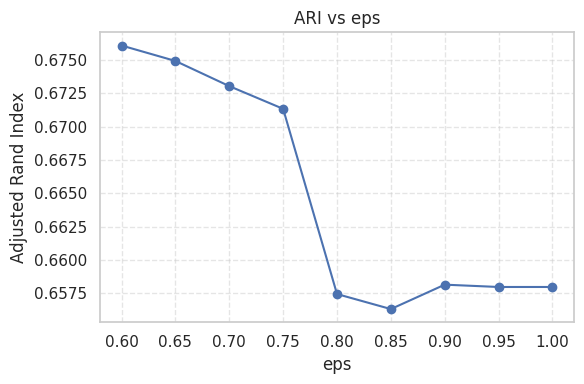

In [58]:
eps_list, clusters_list, noise_list, ari_scores = zip(*results)

plt.figure(figsize=(6, 4))
plt.plot(eps_list, ari_scores, marker='o')

plt.title("ARI vs eps")
plt.xlabel("eps")
plt.ylabel("Adjusted Rand Index")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Let's look at epsilon = 0.6

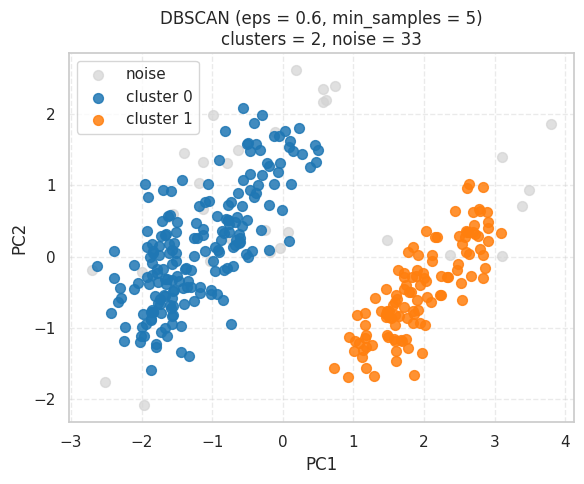

In [59]:
eps = 0.6
min_samples = 5


model = DBSCAN(eps=eps, min_samples=min_samples)
labels = model.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)


# ============================================================
# PCA projection for visualization
# ============================================================

pca = PCA(n_components=2, random_state=170)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))

cmap = plt.get_cmap("tab10")

for lab in np.unique(labels):
    mask = labels == lab

    if lab == -1:
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c="lightgray", s=50, alpha=0.7, label="noise"
        )
    else:
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            color=cmap(lab % 10), s=50, alpha=0.85,
            label=f"cluster {lab}"
        )

plt.title(f"DBSCAN (eps = {eps}, min_samples = {min_samples})\n"
          f"clusters = {n_clusters}, noise = {n_noise}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.4)

handles, labels_leg = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_leg, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

# Gaussian Mixture Models

Every Gaussian distribution is characterised by a mean, which is represented by 
a point in the space of datapoints.  
There are some points that may belong, with different probabilities, to several
clusters.  
In GMM, an indirect way to identify noise points is by focusing on points that have
a very low probability to belong to all clusters.

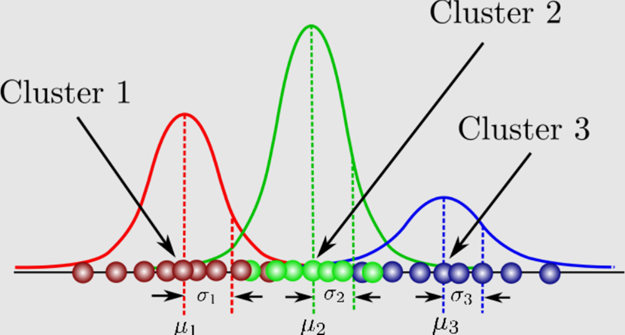

## Iterative Simulation

As k-means, GMM requires to define a-priori the number of clusters and starts
with a random clustering

In [60]:
from scipy.stats import multivariate_normal
from scipy.stats import norm

In [61]:
def plot_pdf(mu, sigma, label, alpha=0.5, linestyle='k--', density=True, color='green'):
    """
    Plot 1-D data and its PDF curve.

    Parameters
    ----------
    X : array-like, shape (n_samples,)
        The input data.
    """
    X = norm.rvs(mu, sigma, size=1000)

    plt.hist(X, bins=50, density=density,
             alpha=alpha, label=label, color=color)

    # Plot the PDF
    x = np.linspace(X.min(), X.max(), 1000)
    y = norm.pdf(x, mu, sigma)
    plt.plot(x, y, linestyle)

In [62]:
n_samples = 100
mu1, sigma1 = -5, 1.2
mu2, sigma2 = 5, 1.8
mu3, sigma3 = 0, 1.6

x1 = np.random.normal(loc=mu1, scale=np.sqrt(sigma1), size=n_samples)
x2 = np.random.normal(loc=mu2, scale=np.sqrt(sigma2), size=n_samples)
x3 = np.random.normal(loc=mu3, scale=np.sqrt(sigma3), size=n_samples)

X = np.concatenate((x1, x2, x3))

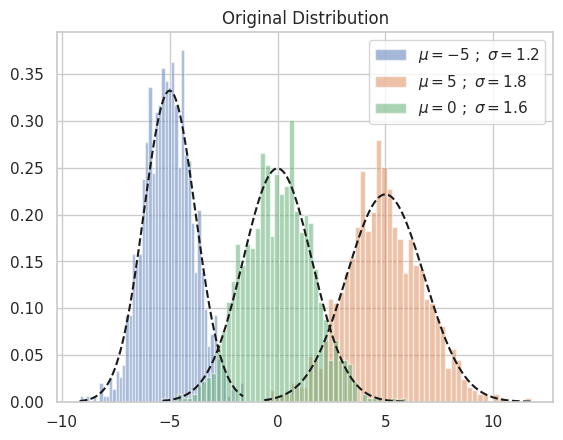

In [63]:
plot_pdf(mu1, sigma1, label=r"$\mu={} \ ; \ \sigma={}$".format(
    mu1, sigma1), color=None)
plot_pdf(mu2, sigma2, label=r"$\mu={} \ ; \ \sigma={}$".format(
    mu2, sigma2), color=None)
plot_pdf(mu3, sigma3, label=r"$\mu={} \ ; \ \sigma={}$".format(
    mu3, sigma3), color=None)
plt.title("Original Distribution")
plt.legend()
plt.show()

In [64]:
def random_init(n_components):
    """Initialize means, weights and variance randomly"""

    pi = np.ones((n_components)) / n_components
    means = np.random.choice(X, n_components)
    variances = np.random.random_sample(size=n_components)
    plot_pdf(means[0], variances[0], 'Random Init 01',)
    plot_pdf(means[1], variances[1], 'Random Init 02', color='blue')
    plot_pdf(means[2], variances[2], 'Random Init 03', color='orange')

    plt.title("Random Initialization")

    plt.legend()
    plt.show()

    return means, variances, pi

In [65]:
def step_expectation(X, n_components, means, variances):
    """E Step

    Parameters
    ----------
    X : array-like, shape (n_samples,)
        The data.
    n_components : int
        The number of clusters
    means : array-like, shape (n_components,)
        The means of each mixture component.
    variances : array-like, shape (n_components,)
        The variances of each mixture component.

    Returns
    -------
    weights : array-like, shape (n_components,n_samples)
    """
    weights = np.zeros((n_components, len(X)))
    for j in range(n_components):
        weights[j, :] = norm(loc=means[j], scale=np.sqrt(variances[j])).pdf(X)
    return weights

Reassing mean, variance and weight to clusters based on the current location 
of points

In [66]:
def step_maximization(X, weights, means, variances, n_components, pi):
    """M Step

    Parameters
    ----------
    X : array-like, shape (n_samples,)
        The data.
    weights : array-like, shape (n_components,n_samples)
        initilized weights array
    means : array-like, shape (n_components,)
        The means of each mixture component.
    variances : array-like, shape (n_components,)
        The variances of each mixture component.
    n_components : int
        The number of clusters
    pi: array-like (n_components,)
        mixture component weights

    Returns
    -------
    means : array-like, shape (n_components,)
        The means of each mixture component.
    variances : array-like, shape (n_components,)
        The variances of each mixture component.
    """
    r = []
    for j in range(n_components):
        r.append((weights[j] * pi[j]) / (np.sum([weights[i] * pi[i]
                 for i in range(n_components)], axis=0)))

        means[j] = np.sum(r[j] * X) / (np.sum(r[j]))
        variances[j] = np.sum(r[j] * np.square(X - means[j])) / (np.sum(r[j]))

        pi[j] = np.mean(r[j])

    return variances, means, pi

In [67]:
def plot_intermediate_steps(means, variances, step):

    plot_pdf(mu1, sigma1, alpha=0.0, linestyle='r--',
             label='Original Distibutions')
    plot_pdf(mu2, sigma2, alpha=0.0, linestyle='r--',
             label='Original Distibutions')
    plot_pdf(mu3, sigma3, alpha=0.0, linestyle='r--',
             label='Original Distibutions')

    color_gen = (x for x in ['green', 'blue', 'orange'])

    for mu, sigma in zip(means, variances):
        plot_pdf(mu, sigma, alpha=0.5, label='d', color=next(color_gen))
    plt.title(f"step: {step}")
    plt.show()

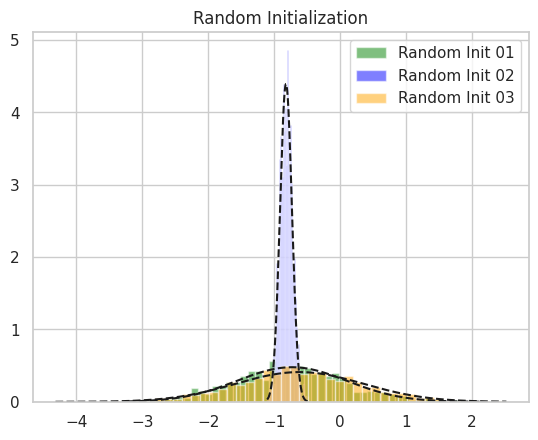

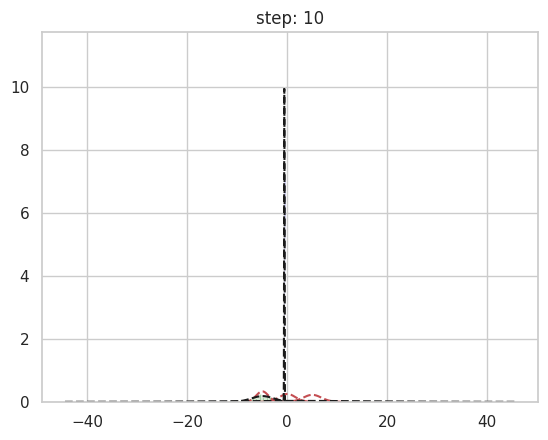

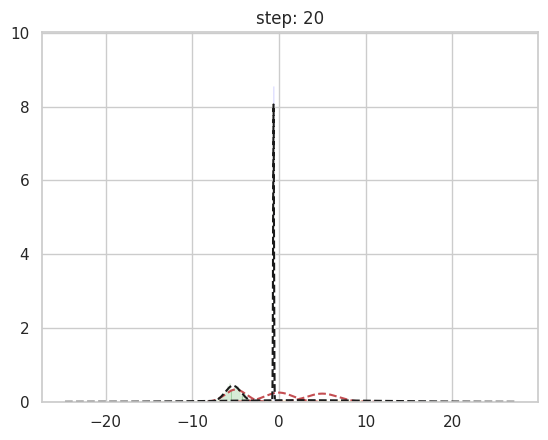

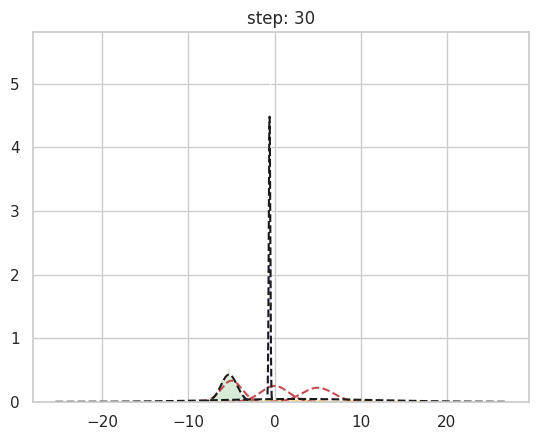

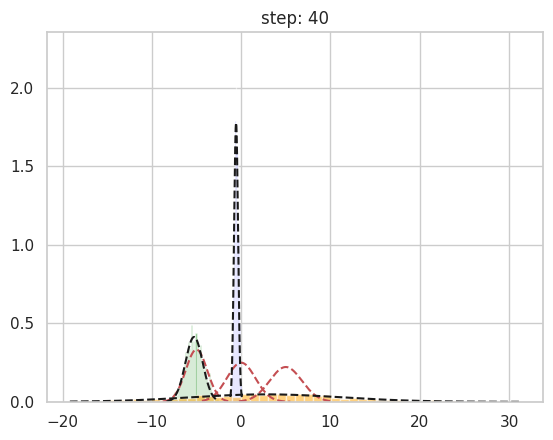

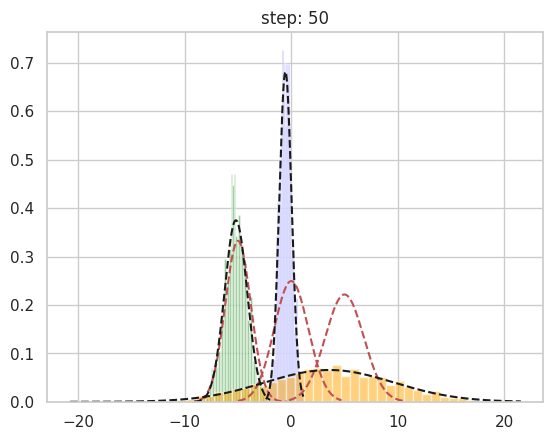

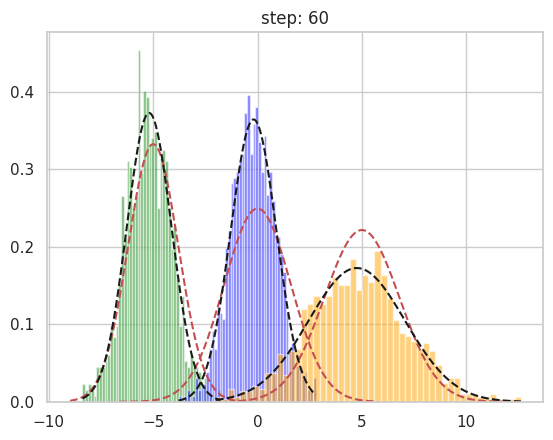

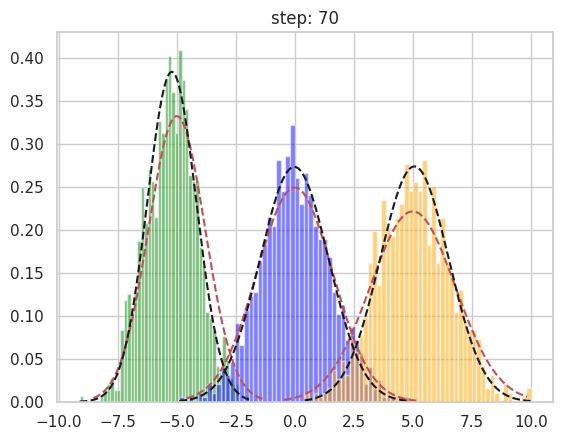

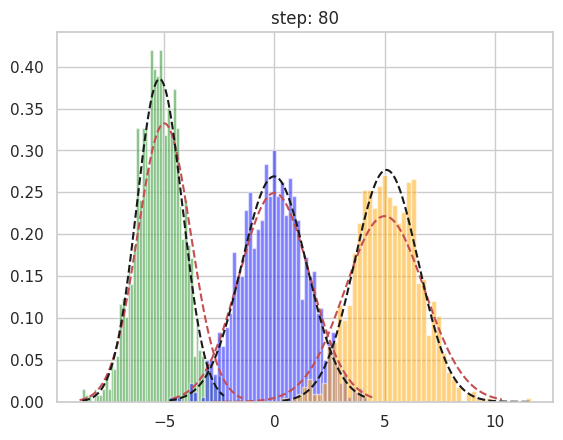

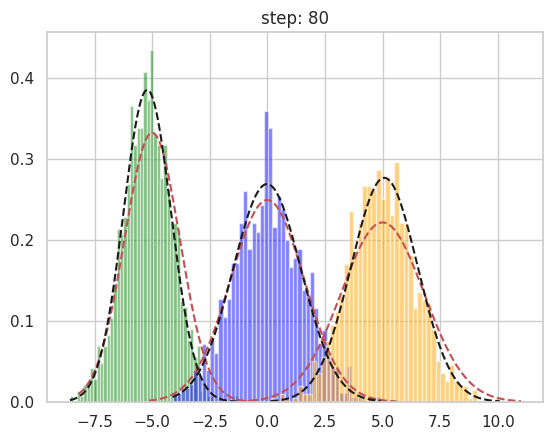

In [68]:
n_components = 3
n_steps = 80

means, variances, pi = random_init(n_components)
for step in range(1, n_steps+1):
    weights = step_expectation(X, n_components, means, variances)
    variances, means, pi = step_maximization(
        X, weights, means, variances, n_components, pi)
    if step % 10 == 0:
        plot_intermediate_steps(means, variances, step)
plot_intermediate_steps(means, variances, step)

## Iris

We load again the Iris data we already used with K-Means

In [69]:
iris_data = load_iris()
iris4 = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
species_name = iris_data.target
iris = iris4.copy()

We define a useful function to plot covariance determined by GMM

In [70]:
def plot_covariance_ellipse(ax, mean, cov, color):
    """Plot a Gaussian covariance ellipse."""
    if cov.shape == (2, 2):  # Full covariance
        U, S, Vt = np.linalg.svd(cov)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(S)  # 2 standard deviations
    else:  # Diagonal covariance
        angle = 0
        width, height = 2 * np.sqrt(cov)

    ellipse = Ellipse(mean, width, height, angle=angle, edgecolor=color,
                      facecolor='none', linestyle='--', linewidth=2)
    ax.add_patch(ellipse)

And let's run the GMM clustering on the Iris data  
`covariance_type` is the second hyperparameter to GMM; the most common choice 
(and even the default one) is 
to set it to `full`

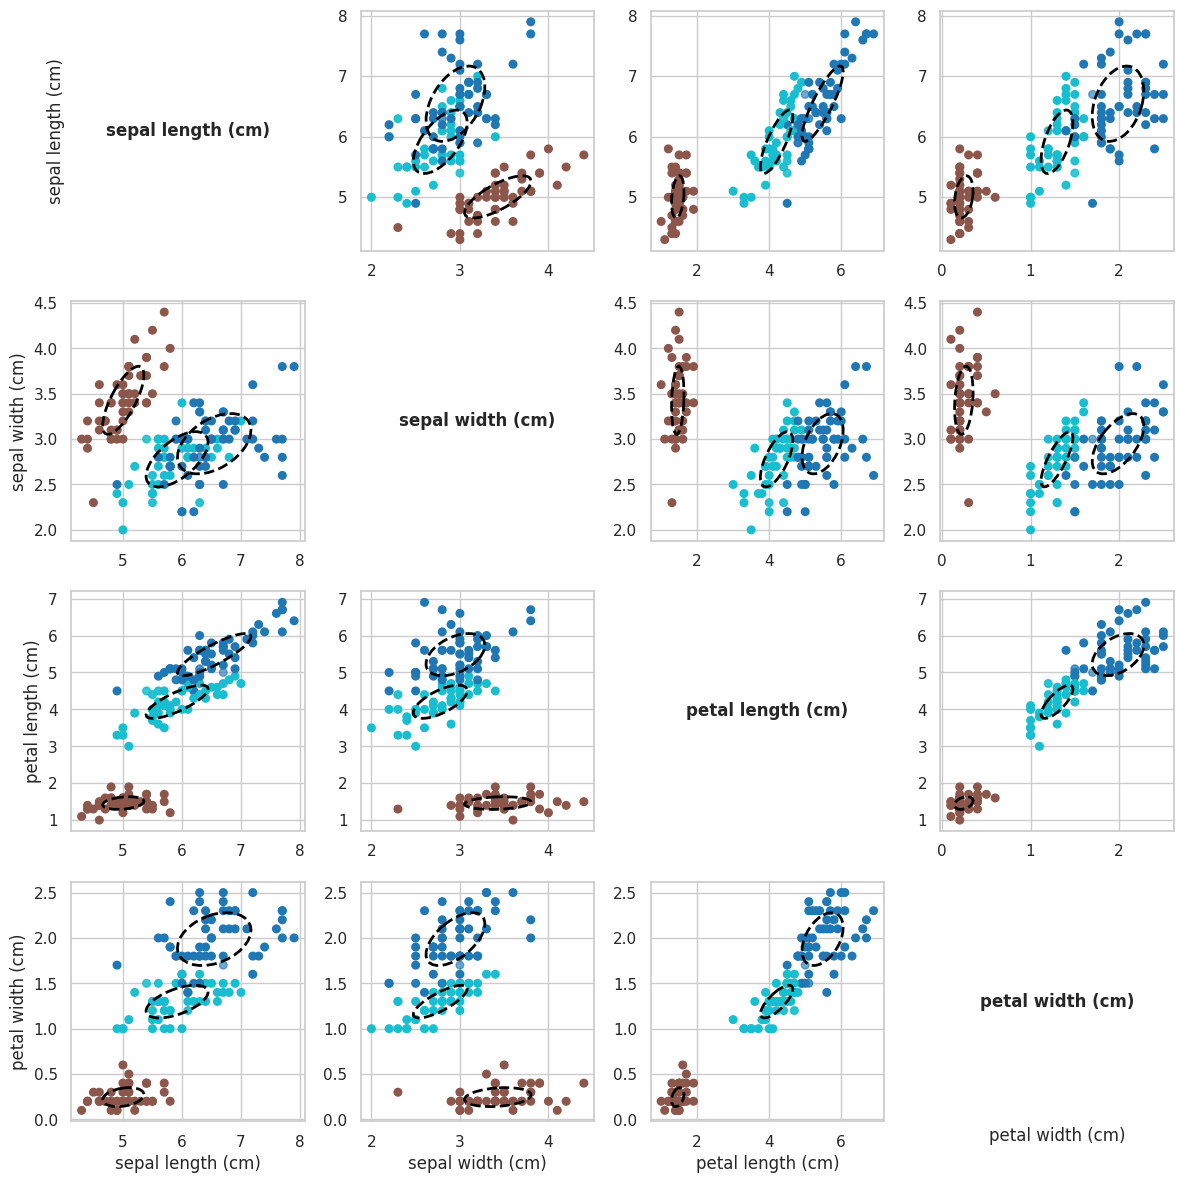

In [71]:
# Fit GMM with 3 clusters (since we know Iris has 3 species)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(iris)

# Predict cluster assignments and probabilities
clusters = gmm.predict(iris)
probabilities = gmm.predict_proba(iris)

# Create pairwise scatter plots
sns.set(style="whitegrid")
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
features = iris.columns
num_features = len(features)
cmap = cm.get_cmap('tab10', 3)

# Loop through feature pairs
for i in range(num_features):
    for j in range(num_features):
        ax = axes[i, j]

        # Diagonal: Show feature names
        if i == j:
            ax.text(0.5, 0.5, features[i], ha='center',
                    va='center', fontsize=12, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(False)
        else:
            # Scatter plot
            norm = Normalize(vmin=0, vmax=1)
            # Assign colors based on cluster
            colors = np.array([cmap(k) for k in clusters])
            # Adjust transparency by probability
            colors[:, -1] = norm(probabilities.max(axis=1))

            ax.scatter(iris.iloc[:, j], iris.iloc[:, i], s=30, color=colors)

            # Plot covariance ellipses
            for k in range(gmm.n_components):
                mean = gmm.means_[k][[j, i]]  # Select only relevant dimensions
                # Extract 2x2 covariance matrix
                cov = gmm.covariances_[k][np.ix_([j, i], [j, i])]
                plot_covariance_ellipse(ax, mean, cov, color='black')

        # Set labels
        if i == num_features - 1:
            ax.set_xlabel(features[j])
        if j == 0:
            ax.set_ylabel(features[i])

plt.tight_layout()
plt.show()

A vertical ellipse, like the one featured by the brown cluster, highlight a 
large variance, with a clear direction of maximum variability

Let's compare k-means and GMM on Iris in terms of ARI:

In [72]:
# Apply K-Means clustering
kmeans_iris = KMeans(n_clusters=3, random_state=42)
predicted_labels_kmeans = kmeans_iris.fit_predict(iris)

# Apply Gaussian Mixture Model (GMM) clustering
gmm_iris = GaussianMixture(n_components=3, random_state=42)
predicted_labels_gmm = gmm_iris.fit_predict(iris)

# Compute ARI for both methods
ari_kmeans = adjusted_rand_score(species_name, predicted_labels_kmeans)
ari_gmm = adjusted_rand_score(species_name, predicted_labels_gmm)

ari_comparison = pd.DataFrame({
    "Clustering Method": ["K-Means", "Gaussian Mixture Model (GMM)"],
    "ARI Score": [ari_kmeans, ari_gmm]
})

ari_comparison

,Clustering Method,ARI Score
0,K-Means,0.716342
1,Gaussian Mixture Model (GMM),0.903874


GMM is better in capturing the species subdivision than k-means, as confirmed by 
an higher ARI Score

### Covariance Matrix, AIC and BIC

With GMM we can have different covariance matrices:


*   Full - every component has a full covariance matrix
*   Tied - all components share a single cov matrix - $\Sigma_k = \Sigma$; $\Sigma$ can be thought as the mean covariance matrix of all components. Tied covariance matrix is useful for reducing the number of parameters used when working with few datapoints 
*   Spherical - each component has its own isotropic cov matrix $\Sigma_k = \sigma_k^2 \cdot I $; even in this case, the number of parameters the algorithm is going to fit is low
*   Diagonal - $\Sigma_k = diag(\sigma_{k,1}^2, ..., \sigma_{k,d}^2)$; zero entries in $\Sigma_k$ correspond to independent variables

In general, covariance matrices, other than `full`, are used to obviate the absence of information about the dataset with a try-and-error approach

With models characterized by a set of parameters $\theta$ of size $k$ and a likelihood of the data ($l$) it is possible to use two specific measures to evaluate quality:

$AIC = 2k -2l(\theta)$

$BIC = klog(n) - 2l(\theta)$

Both are useful only for comparison (not in absolute terms) and penalize excessive model complexity while favoring likelihood of the data  
Tipically, AIC and BIC are in agreement in their value

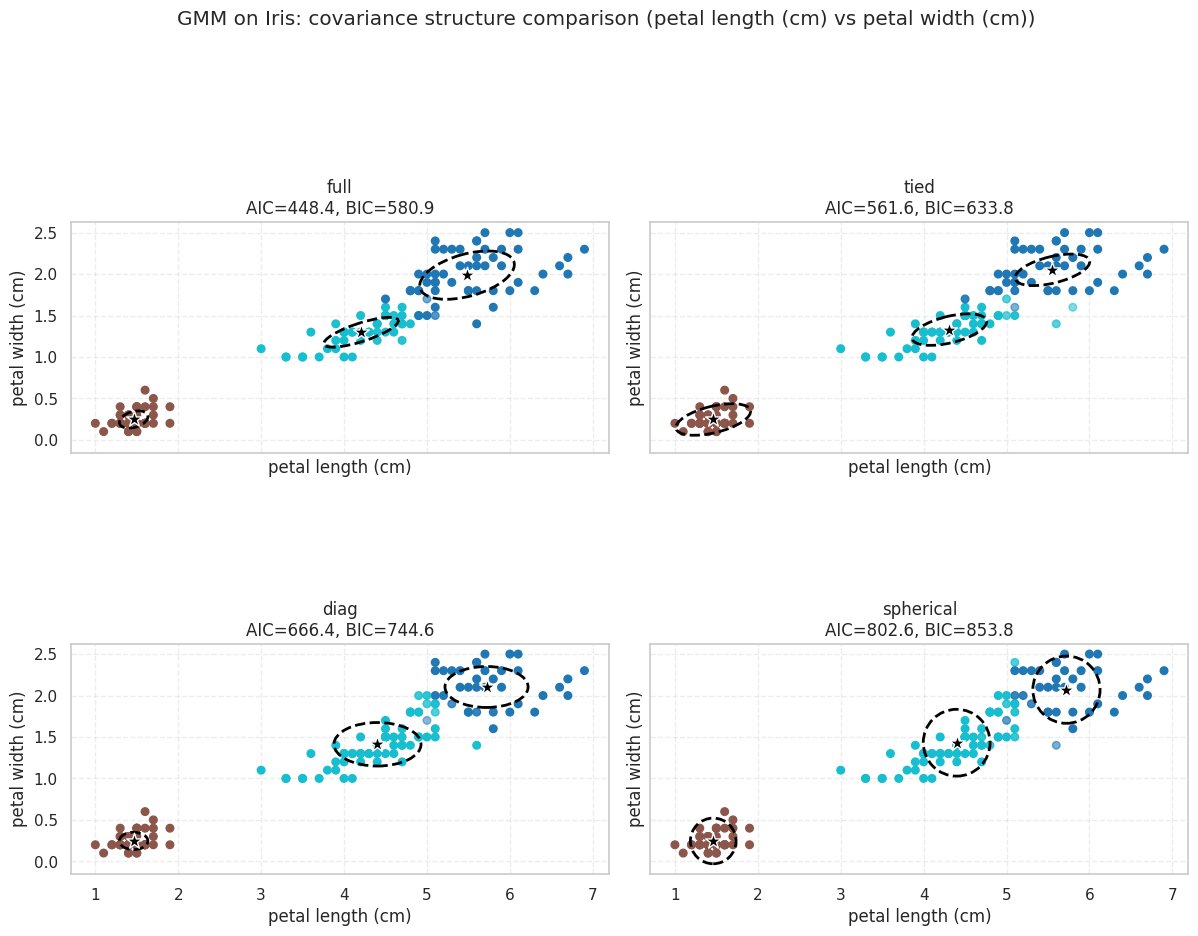

,covariance_type,AIC,BIC
0,full,448.393326,580.861278
1,tied,561.591000,633.846247
2,diag,666.363843,744.640361
3,spherical,802.642777,853.823577


In [73]:
n_components = 3
covariance_types = ["full", "tied", "diag", "spherical"]

# Choose one pair of features
j, i = 2, 3
x_name = iris.columns[j]
y_name = iris.columns[i]

results = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for ax, cov_type in zip(axes.ravel(), covariance_types):
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type=cov_type,
        random_state=42
    )
    gmm.fit(iris)

    clusters = gmm.predict(iris)
    probabilities = gmm.predict_proba(iris)
    max_prob = probabilities.max(axis=1)    # hard clustering

    cmap = cm.get_cmap("tab10", n_components)
    colors = np.array([cmap(k) for k in clusters])
    colors[:, -1] = Normalize(vmin=0, vmax=1)(max_prob)

    ax.scatter(
        iris.iloc[:, j],
        iris.iloc[:, i],
        s=30,
        color=colors
    )
    ax.set_aspect('equal')

    for k in range(gmm.n_components):
        mean_2d = gmm.means_[k][[j, i]]

        if cov_type == "full":
            cov_2d = gmm.covariances_[k][np.ix_([j, i], [j, i])]
        elif cov_type == "tied":
            cov_2d = gmm.covariances_[np.ix_([j, i], [j, i])]
        elif cov_type == "diag":
            cov_2d = np.diag(gmm.covariances_[k][[j, i]])
        elif cov_type == "spherical":
            cov_2d = np.eye(2) * gmm.covariances_[k]

        plot_covariance_ellipse(ax, mean_2d, cov_2d, color="black")
        ax.scatter(
            mean_2d[0], mean_2d[1],
            marker='*', s=140, c='black',
            edgecolors='white', linewidth=1
        )

    aic = gmm.aic(iris)
    bic = gmm.bic(iris)
    results.append({
        "covariance_type": cov_type,
        "AIC": aic,
        "BIC": bic
    })

    ax.set_title(f"{cov_type}\nAIC={aic:.1f}, BIC={bic:.1f}")
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.grid(True, linestyle="--", alpha=0.35)

plt.suptitle(
    f"GMM on Iris: covariance structure comparison ({x_name} vs {y_name})", y=1.02)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).sort_values("BIC")
results_df

# GMM vs DBSCAN vs K-Means in different settings

Let's define a couple of functions to plot clusters in a nice way

In [74]:
# ============================================================
# Helper functions
# ============================================================
def plot_cluster_labels(ax, X, labels, title, centers=None, noise_color='lightgray'):
    """
    Generic scatter plot for clustering results.
    Noise points for DBSCAN (label = -1) are shown in noise_color.
    """
    unique_labels = np.unique(labels)

    # Use tab10 for cluster colors
    cmap = plt.get_cmap("tab10")

    for lab in unique_labels:
        mask = labels == lab
        if lab == -1:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                s=25, c=noise_color, label="noise", alpha=0.8
            )
        else:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                s=25, color=cmap(lab % 10), alpha=0.8
            )

    if centers is not None:
        ax.scatter(
            centers[:, 0], centers[:, 1],
            marker='*', s=220, c='black',
            edgecolors='white', linewidth=1.5
        )

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


def plot_gmm_result(ax, X, model, title):
    """
    Plot GMM hard assignments + Gaussian ellipses.
    """
    labels = model.predict(X)
    probs = model.predict_proba(X)
    max_prob = probs.max(axis=1)

    cmap = plt.get_cmap("tab10")
    colors = np.array([cmap(l % 10) for l in labels])
    colors[:, -1] = np.clip(max_prob, 0.25, 1.0)  # transparency by confidence

    ax.scatter(X[:, 0], X[:, 1], s=25, color=colors)
    ax.scatter(
        model.means_[:, 0], model.means_[:, 1],
        marker='*', s=220, c='black',
        edgecolors='white', linewidth=1.5
    )

    for mean, cov in zip(model.means_, model.covariances_):
        plot_covariance_ellipse(ax, mean, cov, color='black')

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

We experiment on some synthetic datasets with different clustering methods

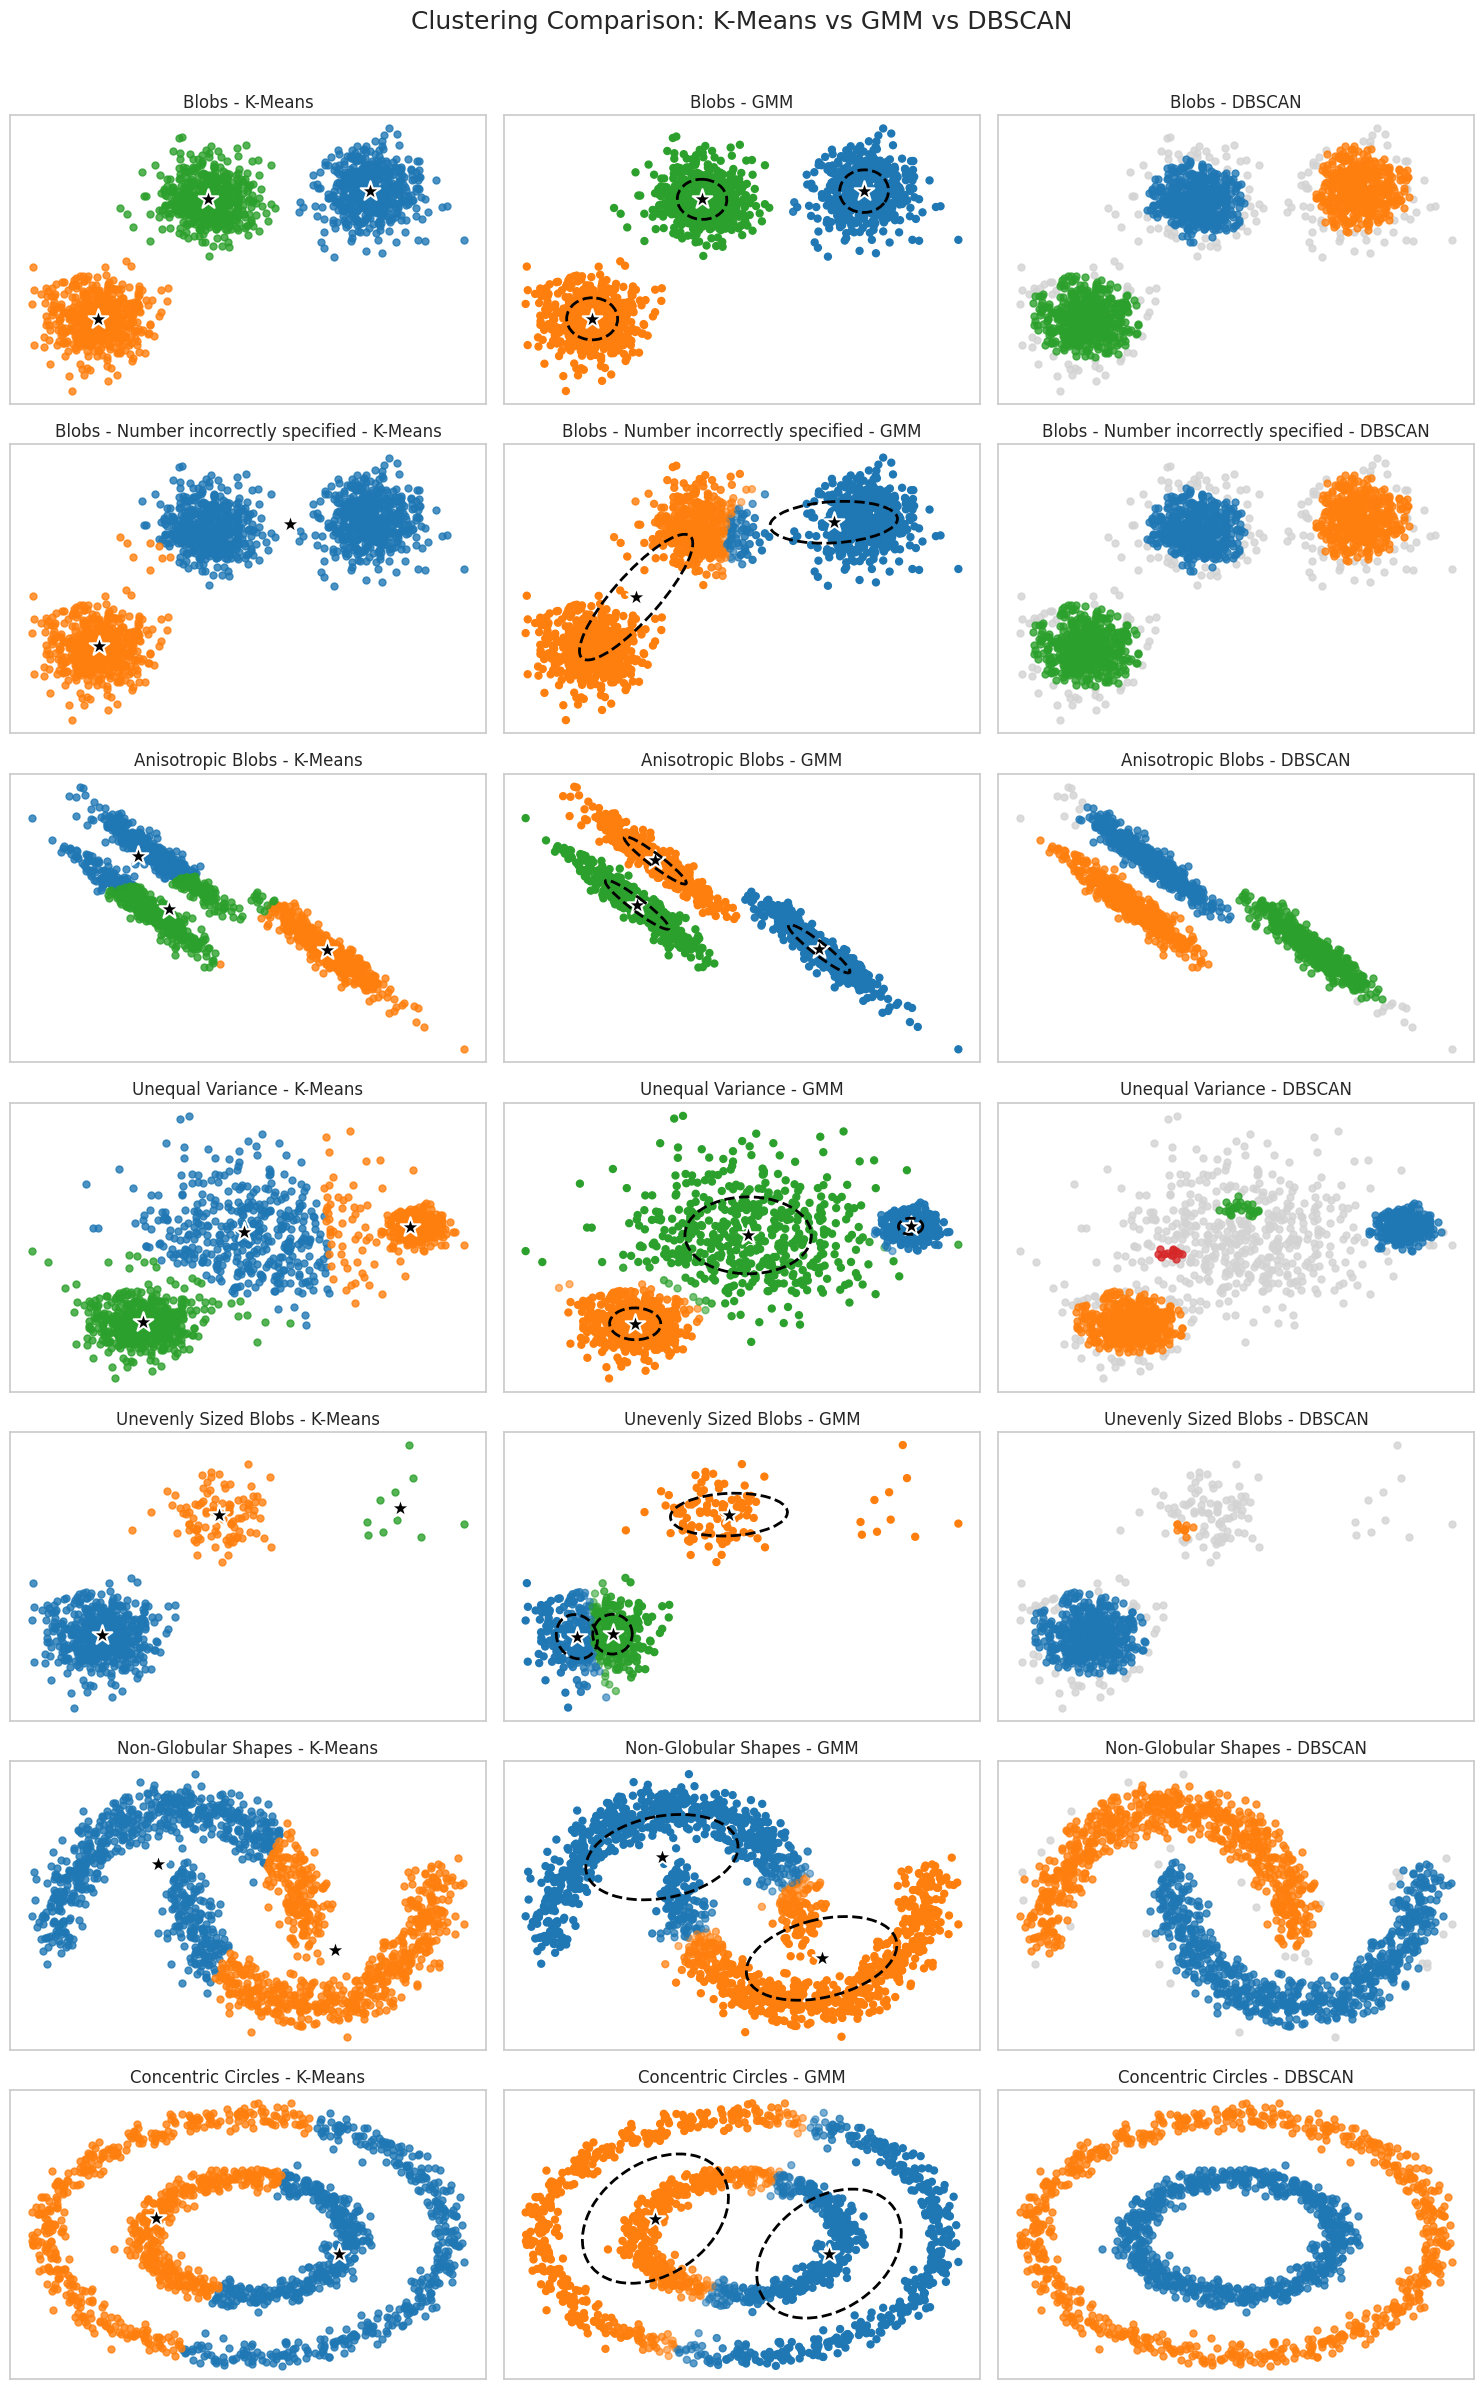

In [75]:
# ============================================================
# Build datasets
# ============================================================

n_samples = 1500
random_state = 170

datasets = []

# 1) Simple blobs
X_blobs, y_blobs = make_blobs(n_samples=n_samples, random_state=random_state)
datasets.append(("Blobs", X_blobs, 3))

# 2) Incorrectly specified blobs
X_blobs, y_blobs = make_blobs(n_samples=n_samples, random_state=random_state)
datasets.append(("Blobs - Number incorrectly specified", X_blobs, 2))

# 3) Anisotropic blobs
transformation = np.array([[0.60834549, -0.63667341],
                           [-0.40887718, 0.85253229]])
X_aniso = np.dot(X_blobs, transformation)
datasets.append(("Anisotropic Blobs", X_aniso, 3))

# 4) Unequal variance
X_varied, y_varied = make_blobs(
    n_samples=n_samples,
    cluster_std=[1.0, 2.5, 0.5],
    random_state=random_state
)
datasets.append(("Unequal Variance", X_varied, 3))

# 5) Unevenly sized blobs
X_uneven = np.vstack((
    X_blobs[y_blobs == 0][:500],
    X_blobs[y_blobs == 1][:100],
    X_blobs[y_blobs == 2][:10]
))
datasets.append(("Unevenly Sized Blobs", X_uneven, 3))

# 6) Non-globular shapes
X_moons, y_moons = make_moons(
    n_samples=n_samples, noise=0.1, random_state=random_state)
datasets.append(("Non-Globular Shapes", X_moons, 2))

# 7) Concentric circles
X_circles, y_circles = make_circles(
    n_samples=n_samples,
    factor=0.5,
    noise=0.05,
    random_state=random_state
)
datasets.append(("Concentric Circles", X_circles, 2))

# ============================================================
# Plot comparison: rows = datasets, cols = methods
# ============================================================

fig, axes = plt.subplots(len(datasets), 3, figsize=(15, 24))
fig.suptitle("Clustering Comparison: K-Means vs GMM vs DBSCAN",
             fontsize=18, y=0.995)

for i, (name, X, n_clusters) in enumerate(datasets):

    # ----------------------------
    # K-Means
    # ----------------------------
    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=random_state, n_init=10)
    km_labels = kmeans.fit_predict(X)
    plot_cluster_labels(
        axes[i, 0], X, km_labels,
        title=f"{name} - K-Means",
        centers=kmeans.cluster_centers_
    )

    # ----------------------------
    # GMM
    # ----------------------------
    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type='full',
        random_state=random_state
    )
    gmm.fit(X)
    plot_gmm_result(
        axes[i, 1], X, gmm,
        title=f"{name} - GMM"
    )

    # ----------------------------
    # DBSCAN
    # ----------------------------
    # Dataset-specific parameters
    if name == "Non-Globular Shapes":
        dbscan = DBSCAN(eps=0.10, min_samples=10)
    elif name == 'Concentric Circles':
        dbscan = DBSCAN(eps=0.20, min_samples=3)
    else:
        dbscan = DBSCAN(eps=0.40, min_samples=10)

    db_labels = dbscan.fit_predict(X)
    plot_cluster_labels(
        axes[i, 2], X, db_labels,
        title=f"{name} - DBSCAN"
    )

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

# Supplementary Material

## DBSCAN on Iris

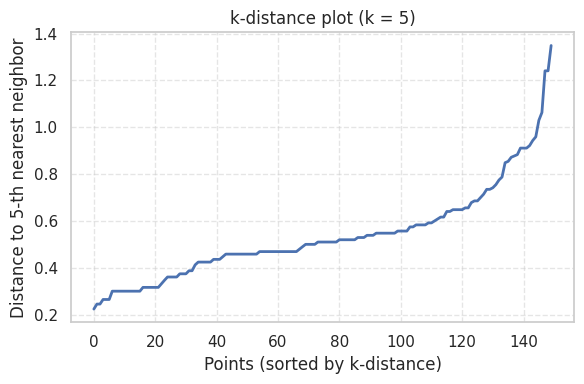

In [76]:
min_pts = 10
nbrs = NearestNeighbors(n_neighbors=min_pts)
nbrs.fit(iris)
distances, _ = nbrs.kneighbors(iris)

# sort the last column of distances in ascending order
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances, linewidth=2)
plt.title(f"k-distance plot (k = {min_pts})")
plt.xlabel("Points (sorted by k-distance)")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

The best `eps` for DBSCAN is in $[0.6, 1.0]$. Let's find out which one is the best
by computing the ARI index for different choices of the value

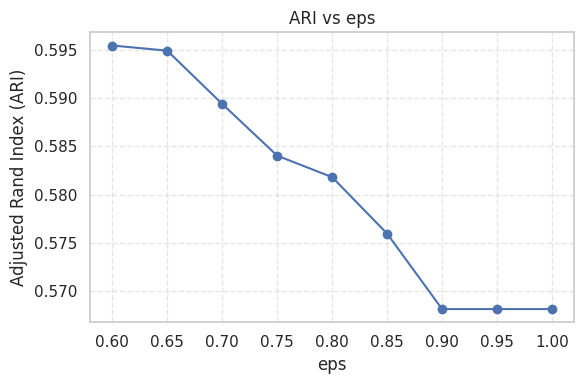

In [77]:
eps_values = np.linspace(0.6, 1.0, 9)

results = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=min_pts)
    labels = model.fit_predict(iris)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    mask = labels != -1

    ari = adjusted_rand_score(species_name[mask], labels[mask])

    results.append((eps, n_clusters, n_noise, ari))

eps_list, clusters_list, noise_list, ari_scores = zip(*results)

plt.figure(figsize=(6, 4))
plt.plot(eps_list, ari_scores, marker='o')

plt.title("ARI vs eps")
plt.xlabel("eps")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

From the ARI vs eps plot, the optimal choice, which maximizes the ARI is for `eps = 0.6`, so we apply DBSCAN for the hyperparameter choice `eps = 0.6` and `min_samples = 10` using PCA for 2D data visualization.

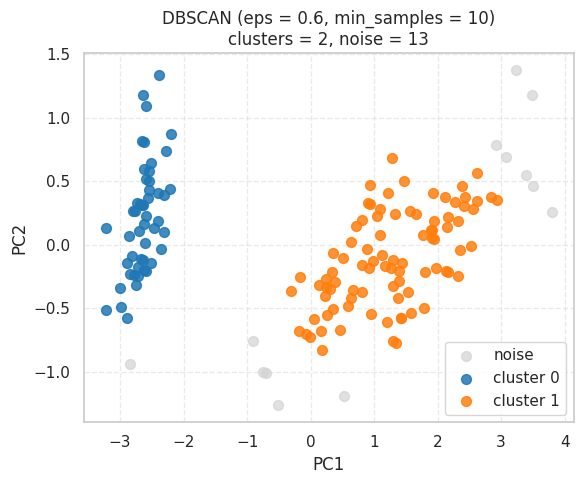

In [78]:
eps = 0.6
min_pts = 10

model = DBSCAN(eps=eps, min_samples=min_pts)
labels = model.fit_predict(iris)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

mask = labels != -1

pca = PCA(n_components=2, random_state=170)
iris_pca = pca.fit_transform(iris)

plt.figure(figsize=(6, 5))

cmap = plt.get_cmap("tab10")

for lab in np.unique(labels):
    mask = labels == lab

    if lab == -1:
        plt.scatter(
            iris_pca[mask, 0], iris_pca[mask, 1],
            c="lightgray", s=50, alpha=0.7, label="noise"
        )
    else:
        plt.scatter(
            iris_pca[mask, 0], iris_pca[mask, 1],
            color=cmap(lab % 10), s=50, alpha=0.85,
            label=f"cluster {lab}"
        )

plt.title(f"DBSCAN (eps = {eps}, min_samples = {min_pts})\n"
          f"clusters = {n_clusters}, noise = {n_noise}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.4)

handles, labels_leg = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_leg, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

DBSCAN manages to identify two clusters in the data, where one corresponding to the class which is linearly separable from the other two, which are not recognized by the algorithm as they appear similar w.r.t. the two PCs.
Despite GMM provides a better clustering, being able to identify all three of them, let's compare k-means and DBSCAN through their ARI.

In [84]:
kmeans_iris = KMeans(n_clusters=3, random_state=42)
predicted_labels_kmeans = kmeans_iris.fit_predict(iris)

ari_kmeans = adjusted_rand_score(species_name, predicted_labels_kmeans)
ari_dbscan = adjusted_rand_score(species_name, labels)

ari_comparison = pd.DataFrame({
    "Clustering Method": ["K-Means", "DBSCAN"],
    "ARI Score": [ari_kmeans, ari_dbscan]
})

ari_comparison

,Clustering Method,ARI Score
0,K-Means,0.716342
1,DBSCAN,0.529964


From ARI index, it is clear that k-means provides a better-quality partitioning of the datapoints in Iris dataset.

## DBSCAN on Chamaleon dataset

In [79]:
# Explore different parameters on the Chamaleon dataset

A possible result:

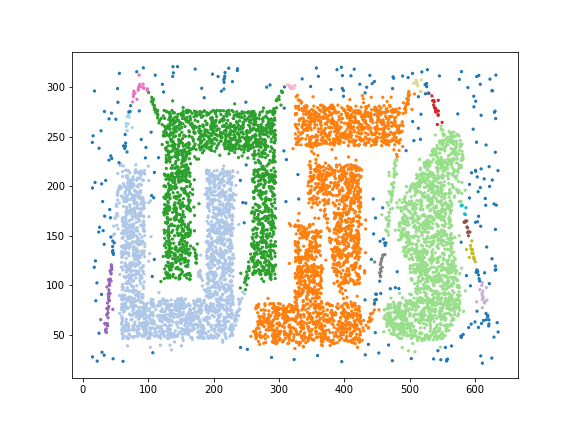

## DBSCAN and GMM on earthquake dataset

Load the earthquake dataset from R via `statsmodel` and plot the data

       lat    long  depth
0   -20.42  181.62  -5.62
1   -20.62  181.03  -6.50
2   -26.00  184.10  -0.42
3   -17.97  181.66  -6.26
4   -20.42  181.96  -6.49
..     ...     ...    ...
995 -25.93  179.54  -4.70
996 -12.28  167.06  -2.48
997 -20.13  184.20  -2.44
998 -17.40  187.80  -0.40
999 -21.59  170.56  -1.65

[1000 rows x 3 columns]


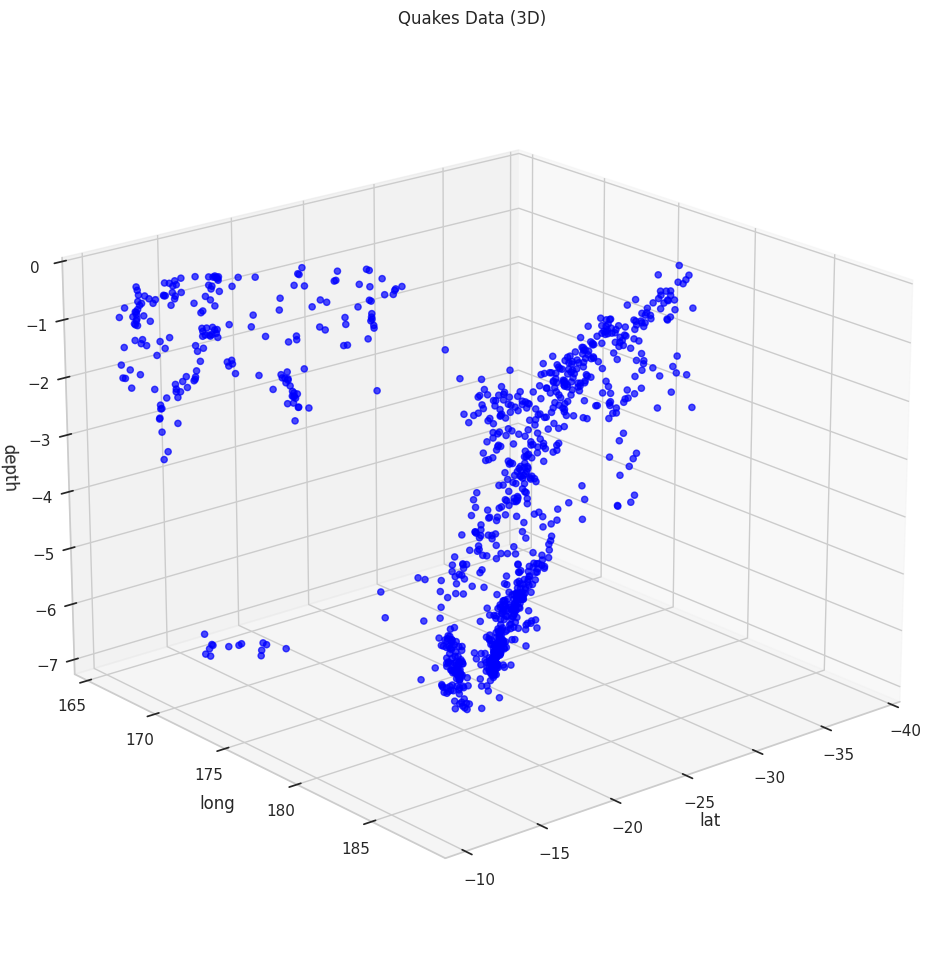

In [ ]:
quakes = sm.datasets.get_rdataset("quakes", "datasets").data
Q = quakes.iloc[:, :2].copy()
Q['depth'] = -quakes.iloc[:, 2] / 100
print(Q)

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Q.iloc[:, 0], Q.iloc[:, 1], Q['depth'], c='blue', s=20, alpha=0.7)
ax.set_xlabel('lat')
ax.set_ylabel('long')
ax.set_zlabel('depth')
ax.set_title("Quakes Data (3D)")
ax.view_init(elev=20, azim=50)
plt.show()

Let's try with DBSCAN first. By normalizing the dataset, we are assigning the same relevance to each one of the features

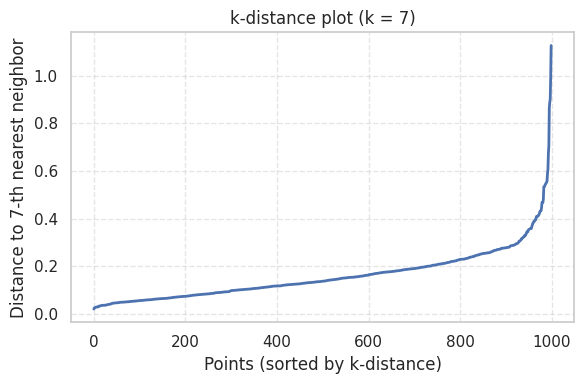

In [92]:
Q = StandardScaler().fit_transform(Q)
min_pts = 7
nbrs = NearestNeighbors(n_neighbors=min_pts)
nbrs.fit(Q)
distances, _ = nbrs.kneighbors(Q)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances, linewidth=2)
plt.title(f"k-distance plot (k = {min_pts})")
plt.xlabel("Points (sorted by k-distance)")
plt.ylabel(f"Distance to {min_pts}-th nearest neighbor")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

The best `eps` for DBSCAN is in $[0.2, 0.4]$. Let's find out which one is the best
by trying different values for `eps` and seeing which one seems to provide a satisfactory clustering.

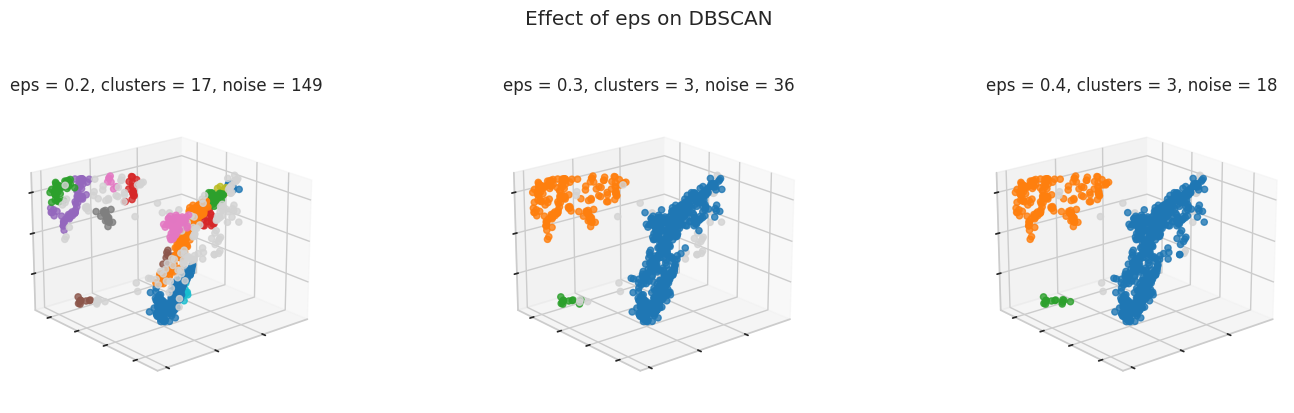

In [ ]:
eps_values = [0.2, 0.3, 0.4]
min_samples = 7

fig, axes = plt.subplots(1, 3, figsize=(
    15, 4), subplot_kw={'projection': '3d'})

for ax, eps in zip(axes, eps_values):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(Q)
    unique_labels = np.unique(labels)

    cmap = plt.get_cmap("tab10")

    for lab in unique_labels:
        mask = labels == lab
        if lab == -1:
            ax.scatter(
                Q[mask, 0], Q[mask, 1], Q[mask, 2],
                s=20, c="lightgray", alpha=0.8
            )
        else:
            ax.scatter(
                Q[mask, 0], Q[mask, 1], Q[mask, 2],
                s=20, color=cmap(lab % 10), alpha=0.8
            )

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    ax.set_title(f"eps = {eps}, clusters = {n_clusters}, noise = {n_noise}")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.view_init(elev=20, azim=50)

plt.suptitle("Effect of eps on DBSCAN", y=1.03)
plt.tight_layout()
plt.show()

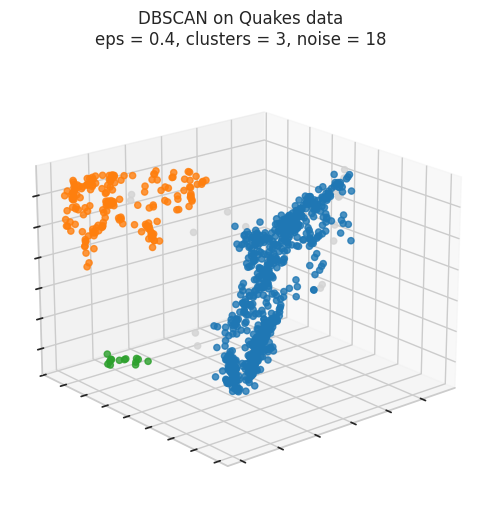

For n_clusters = 3 the average silhouette_score is : 0.3575686075487971


In [ ]:
eps = 0.4
min_samples = 7

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

model = DBSCAN(eps=eps, min_samples=min_samples)
labels = model.fit_predict(Q)
unique_labels = np.unique(labels)

cmap = plt.get_cmap("tab10")

for lab in unique_labels:
    mask = labels == lab
    if lab == -1:
        ax.scatter(
            Q[mask, 0], Q[mask, 1], Q[mask, 2],
            s=20, c="lightgray", alpha=0.8
        )
    else:
        ax.scatter(
            Q[mask, 0], Q[mask, 1], Q[mask, 2],
            s=20, color=cmap(lab % 10), alpha=0.8
        )

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

ax.set_title(f"eps = {eps}, clusters = {n_clusters}, noise = {n_noise}")
ax.grid(True, linestyle="--", alpha=0.4)
ax.tick_params(labelbottom=False, labelleft=False)
ax.view_init(elev=20, azim=50)

plt.title(
    f"DBSCAN on Quakes data\neps = {eps}, clusters = {n_clusters}, noise = {n_noise}")
plt.show()

`eps = 0.4` seems to be able, at least graphically, to distinguish between three clusters (of varying size), marking only a handful of datapoints as noise.  
Now let's try fitting GMM with 3 clusters (the number of clusters we intuitively expect to be present in the dataset) and compare its performance w.r.t. DBSCAN

In [117]:
def plot_covariance_ellipsoid_3d(ax, mean, cov, color='black', n_std=2.0, alpha=0.12):
    """Plot a 3D covariance ellipsoid for one Gaussian component."""
    # Eigen-decomposition gives principal axes directions and variances.
    evals, evecs = np.linalg.eigh(cov)
    evals = np.maximum(evals, 1e-12)
    radii = n_std * np.sqrt(evals)

    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    sphere = np.stack([x, y, z], axis=-1)
    ellipsoid = sphere @ np.diag(radii) @ evecs.T + mean

    ax.plot_wireframe(
        ellipsoid[:, :, 0],
        ellipsoid[:, :, 1],
        ellipsoid[:, :, 2],
        color=color,
        linewidth=0.6,
        alpha=0.6
    )
    ax.plot_surface(
        ellipsoid[:, :, 0],
        ellipsoid[:, :, 1],
        ellipsoid[:, :, 2],
        color=color,
        alpha=alpha,
        linewidth=0
    )

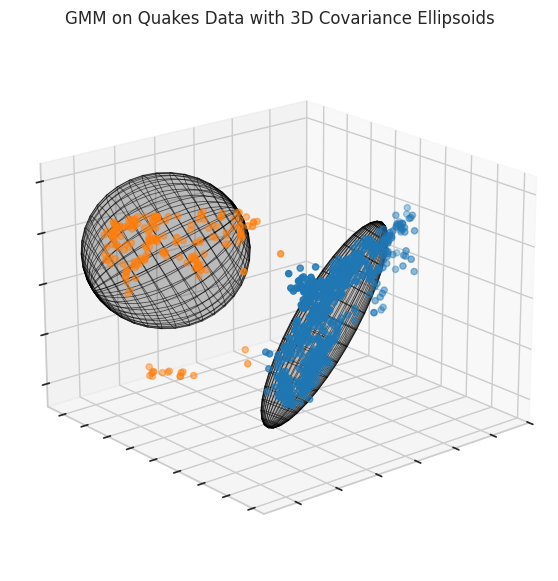

For n_clusters = 3 the average silhouette_score is : 0.4813128555873383


In [ ]:
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(Q)
clusters = gmm.predict(Q)
probabilities = gmm.predict_proba(Q)

norm = Normalize(vmin=0, vmax=1)
colors = np.array([cmap(k) for k in clusters])
colors[:, -1] = norm(probabilities.max(axis=1))

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Q[:, 0], Q[:, 1], Q[:, 2], c=colors, s=20)

# Plot one ellipsoid per Gaussian component
for k in range(gmm.n_components):
    mean = gmm.means_[k]
    cov = gmm.covariances_[k]
    plot_covariance_ellipsoid_3d(ax, mean, cov, color='black', n_std=2.0)

ax.set_title("GMM on Quakes Data with 3D Covariance Ellipsoids")
ax.grid(True, linestyle="--", alpha=0.4)
ax.tick_params(labelbottom=False, labelleft=False)
ax.view_init(elev=20, azim=50)
plt.show()

By forcing the number of components to 2, GMM provides a partitioning of the dataset composed of two distinct clusters with only some points that may be misassigned (due to their placement in the dataspace). This latter aspect may be cleared through a silhouette analysis.  
Moreover, the 3D ellipsoid for the blue cluster gives us a clear idea about the direction of variability of the points in that cluster

For 2 clusters the average silhouette_score is 0.6088


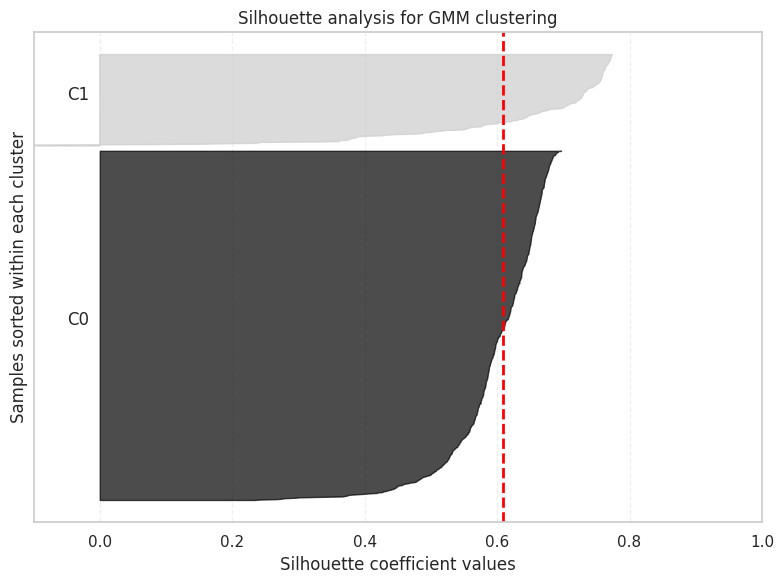

In [ ]:
cluster_ids = np.unique(clusters)
n_clusters = len(cluster_ids)

silhouette_avg = silhouette_score(Q, clusters)
print("For", n_clusters, "clusters the average silhouette_score is",
      round(silhouette_avg, 4))

sample_silhouette_values = silhouette_samples(Q, clusters)

y_lower = 10
fig, ax = plt.subplots(figsize=(8, 6))

for i, cid in enumerate(cluster_ids):
    vals = sample_silhouette_values[clusters == cid]
    vals.sort()

    size_cluster_i = vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / max(n_clusters - 1, 1))
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        vals,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f"C{cid}")
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2)
ax.set_title("Silhouette analysis for GMM clustering")
ax.set_xlabel("Silhouette coefficient values")
ax.set_ylabel("Samples sorted within each cluster")
ax.set_yticks([])
ax.set_xlim([-0.1, 1.0])
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

According to silhouette analysis, no point has been clearly misassigned to any cluster, as it is confirmed by the positive silhouette clustering coefficient `silhouette_avg`

# Feedback

Please leave a feedback on this lab through [this form](https://forms.office.com/e/SvcWG86kjK) (estimated 2 minutes)